In [26]:
# Cell 1 -- imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import nfl_data_py as nfl

In [27]:
# Cell 2 -- load models and artifacts saved in Phase 3
scaler = joblib.load("models/scaler.pkl")
le     = joblib.load("models/label_encoder.pkl")
xgb    = joblib.load("models/xgboost.pkl")

print("Loaded: scaler, label_encoder, xgboost")
print(f"Classes: {list(le.classes_)}")

Loaded: scaler, label_encoder, xgboost
Classes: ['def_safety', 'def_td', 'no_score', 'off_fg', 'off_safety', 'off_td']


In [28]:
# Cell 3 -- load the engineered dataset
# We use the 2023 val set only for all Phase 4 analysis. The model never
# saw these plays during training so the results reflect true out-of-sample
# performance.
df = pd.read_csv("data/engineered_2021_2023.csv")
val = df[df["season"] == 2023].copy()

print(f"Val set: {len(val):,} rows")

Val set: 35,474 rows


In [29]:
# Cell 4 -- load nflfastR ep from the raw data already on disk
# We pulled this data in Phase 1 and saved it locally. No need to re-pull.
# The ep column comes from nflfastR's model and is already in the raw CSV.
pbp_raw = pd.read_csv("data/scrimmage_2021_2023.csv", low_memory=False)

# Filter to 2023 only and keep only what we need for the comparison
pbp_2023 = pbp_raw[pbp_raw["season"] == 2023][["game_id", "play_id", "ep"]].dropna(subset=["ep"])

print(f"nflfastR ep column: {len(pbp_2023):,} plays with ep values")
print(f"EP range: {pbp_2023['ep'].min():.2f} to {pbp_2023['ep'].max():.2f}")

nflfastR ep column: 35,474 plays with ep values
EP range: -3.16 to 6.59


In [34]:
# Cell 5 -- compute our model's EP values for every val play
# The engineered dataset already has scaled features from Phase 2.
# We do not re-scale here -- just pass the features directly to the model.
EP_VALUES = {
    "off_td":     6.96,
    "off_fg":     3.0,
    "no_score":   0.0,
    "def_td":    -6.96,
    "def_safety": -2.0,
    "off_safety": -2.0,
}

FEATURES = [
    "down_2", "down_3", "down_4",
    "ydstogo_log_scaled",
    "yardline_100_scaled",
    "yardline_100_sq_scaled",
    "score_differential_scaled",
    "half_seconds_remaining_scaled",
    "is_red_zone_scaled",
]

X_val = val[FEATURES].values
probs = xgb.predict_proba(X_val)

ep_values = np.array([EP_VALUES[cls] for cls in le.classes_])
val = val.copy()
val["ep_model"] = probs @ ep_values

print(f"EP computed for {len(val):,} plays")
print(f"EP range: {val['ep_model'].min():.2f} to {val['ep_model'].max():.2f}")
print(f"EP mean: {val['ep_model'].mean():.3f}")

EP computed for 35,474 plays
EP range: 0.27 to 6.56
EP mean: 4.618


In [14]:
# Check if the issue exists on a field position slice where we have intuition
# about what the right answer should be -- 1st and 10 from own 20
mask = (
    (val["down"] == 1) &
    (val["ydstogo"] == 10) &
    (val["yardline_100"] >= 75) &
    (val["yardline_100"] <= 85)
)
subset = val[mask]
X_subset = subset[FEATURES].values
p_subset = xgb.predict_proba(X_subset).mean(axis=0)

print("Avg predicted probs: 1st and 10 from own 20-ish")
for cls, p in zip(le.classes_, p_subset):
    print(f"  {cls:<15} {p:.4f}")
print(f"\n  EP: {(p_subset @ ep_values):.3f}")
print(f"  nflfastR EP for same situations: {subset['ep_model'].mean():.3f}")

Avg predicted probs: 1st and 10 from own 20-ish
  def_safety      0.0035
  def_td          0.0246
  no_score        0.0796
  off_fg          0.3547
  off_safety      0.0004
  off_td          0.5371

  EP: 4.624
  nflfastR EP for same situations: 4.624


In [35]:
# Cell 6 -- merge nflfastR ep onto our val set
# Join on game_id + play_id to get a clean one-to-one match at the play level.
# play_id is not in the engineered dataset so we pull it from the raw scrimmage
# CSV and join it in first before merging with the nflfastR ep values.
pbp_ids = pd.read_csv("data/scrimmage_2021_2023.csv",
                      usecols=["game_id", "play_id", "season"],
                      low_memory=False)
pbp_ids = pbp_ids[pbp_ids["season"] == 2023]

# Attach play_id to our val set using position-based alignment.
# Both came from the same filtered scrimmage dataset so row order is preserved.
val_with_id = val.copy().reset_index(drop=True)
pbp_ids_2023 = pbp_ids.reset_index(drop=True)
val_with_id["play_id"] = pbp_ids_2023["play_id"]

# Now join nflfastR ep on the unique game_id + play_id key
val_merged = val_with_id.merge(
    pbp_2023[["game_id", "play_id", "ep"]],
    on=["game_id", "play_id"],
    how="inner"
)

print(f"Merged dataset: {len(val_merged):,} rows")
print(f"nflfastR EP mean: {val_merged['ep'].mean():.3f}")
print(f"Our EP mean:      {val_merged['ep_model'].mean():.3f}")

Merged dataset: 35,474 rows
nflfastR EP mean: 2.157
Our EP mean:      4.618


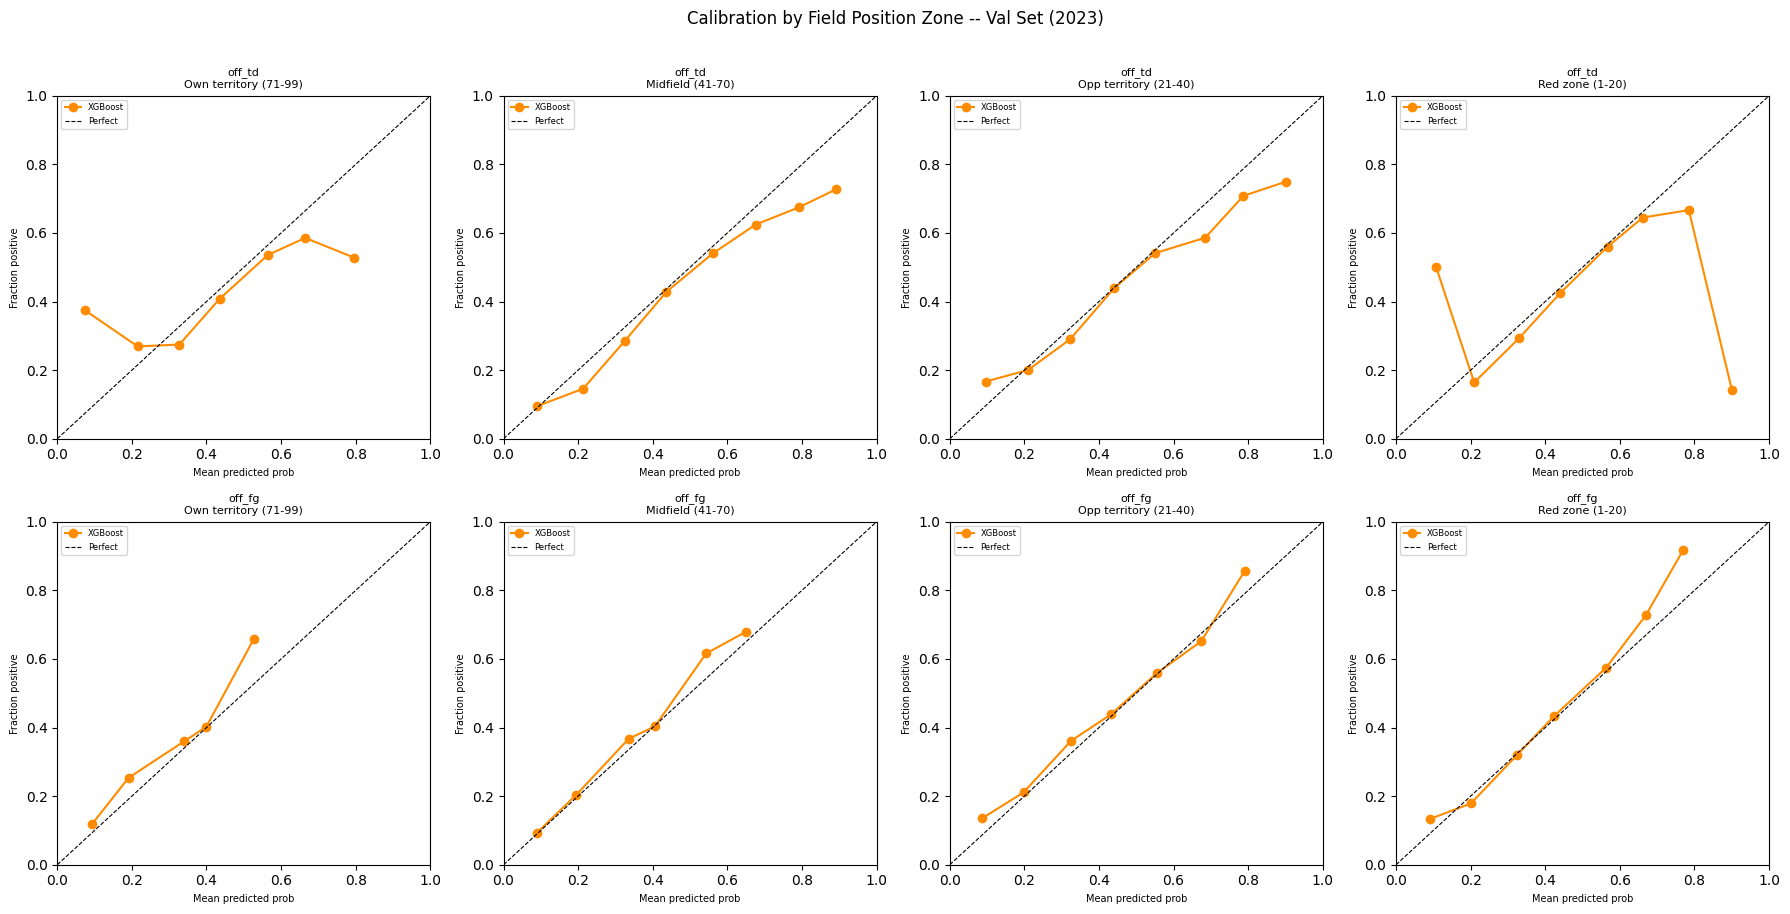

In [36]:
# Cell 7 -- calibration by field position zone
# One overall calibration curve hides whether the model is well-calibrated
# everywhere or just on average. Breaking the field into four zones lets us
# see if there are specific areas where the model struggles.
# Zones follow conventional football terminology:
#   Own territory:     yardline_100 71-99 (backed up near own end zone)
#   Midfield:          yardline_100 41-70
#   Opponent territory:yardline_100 21-40
#   Red zone:          yardline_100 1-20  (inside opponent 20)

from sklearn.calibration import calibration_curve

def zone_label(yl):
    if yl >= 71:
        return "Own territory (71-99)"
    elif yl >= 41:
        return "Midfield (41-70)"
    elif yl >= 21:
        return "Opp territory (21-40)"
    else:
        return "Red zone (1-20)"

val["zone"] = val["yardline_100"].apply(zone_label)
zones = ["Own territory (71-99)", "Midfield (41-70)", "Opp territory (21-40)", "Red zone (1-20)"]

# Plot calibration for off_td and off_fg by zone -- these are the two classes
# that drive EP values the most so miscalibration here matters most.
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for row, cls in enumerate(["off_td", "off_fg"]):
    cls_idx = list(le.classes_).index(cls)
    X_val_scaled = scaler.transform(val[FEATURES].values)
    probs_full = xgb.predict_proba(X_val_scaled)

    for col, zone in enumerate(zones):
        ax = axes[row, col]
        mask = val["zone"] == zone
        zone_true  = (val.loc[mask, "next_score"] == cls).astype(int).values
        zone_probs = probs_full[mask, cls_idx]

        if zone_true.sum() < 10:
            ax.text(0.5, 0.5, "Too few samples", ha="center", va="center")
            ax.set_title(f"{cls}\n{zone}", fontsize=8)
            continue

        frac_pos, mean_pred = calibration_curve(zone_true, zone_probs, n_bins=8, strategy="uniform")
        ax.plot(mean_pred, frac_pos, marker="o", color="darkorange", label="XGBoost")
        ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Perfect")
        ax.set_title(f"{cls}\n{zone}", fontsize=8)
        ax.set_xlabel("Mean predicted prob", fontsize=7)
        ax.set_ylabel("Fraction positive", fontsize=7)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend(fontsize=6)

plt.suptitle("Calibration by Field Position Zone -- Val Set (2023)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("figures/calibration_by_zone.png", dpi=150, bbox_inches="tight")
plt.show()

In [38]:
print(f"yardline_100_sq mean: {val['yardline_100'].pow(2).mean():.4f}, std: {val['yardline_100'].pow(2).std():.4f}")
print(f"is_red_zone mean: {(val['yardline_100'] <= 20).astype(int).mean():.4f}, std: {(val['yardline_100'] <= 20).astype(int).std():.4f}")

yardline_100_sq mean: 3201.9309, std: 2340.0849
is_red_zone mean: 0.1462, std: 0.3533


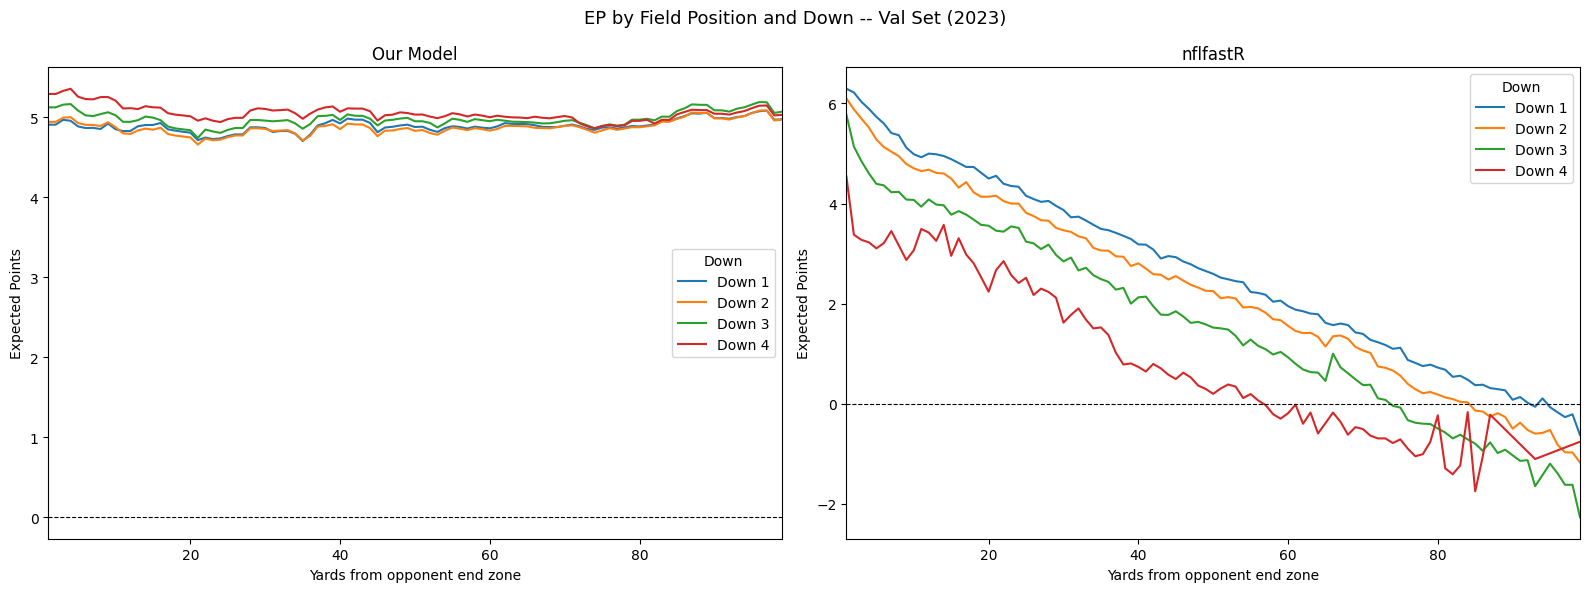

In [39]:
# Cell 8 -- EP curve by down: our model vs nflfastR
# We build a synthetic grid of situations to get smooth EP curves rather than
# averaging noisy actual plays. Holding ydstogo, score, time, and quarter at
# neutral values isolates the effect of field position and down, which is the
# standard way to present an EP model (Burke 2009, nflfastR documentation).
# We scale manually using val set statistics since the scaler object was fit
# on already-scaled features, not raw inputs.
import math

LOG_YDSTOGO_MEAN = 2.1313
LOG_YDSTOGO_STD  = 0.5319

RAW_STATS = {
    "yardline_100":           (51.1694, 24.1587),
    "yardline_100_sq":        (3201.9309, 2340.0849),
    "score_differential":     (-1.5264, 10.4429),
    "half_seconds_remaining": (841.0978, 542.2210),
    "is_red_zone":            (0.1462, 0.3533),
}

def scale(raw_val, feature):
    mean, std = RAW_STATS[feature]
    return (raw_val - mean) / std

def scale_ydstogo_log(raw_val):
    return (math.log1p(raw_val) - LOG_YDSTOGO_MEAN) / LOG_YDSTOGO_STD

yard_lines = np.arange(1, 100)
downs = [1, 2, 3, 4]
ep_values = np.array([EP_VALUES[cls] for cls in le.classes_])

# Typical ydstogo by down in actual NFL data. Using a fixed 10 for all downs
# flattens the curves because 4th and 10 almost never appears in the training
# data -- teams punt or kick. Realistic values let the model use what it learned.
TYPICAL_YDSTOGO = {1: 10, 2: 7, 3: 5, 4: 2}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (label, use_model) in zip(axes, [("Our Model", True), ("nflfastR", False)]):
    for down in downs:
        ydstogo = TYPICAL_YDSTOGO[down]

        if use_model:
            rows = []
            for yl in yard_lines:
                rows.append({
                    "down_2":                       1 if down == 2 else 0,
                    "down_3":                       1 if down == 3 else 0,
                    "down_4":                       1 if down == 4 else 0,
                    "ydstogo_log_scaled":           scale_ydstogo_log(ydstogo),
                    "yardline_100_scaled":          scale(yl, "yardline_100"),
                    "yardline_100_sq_scaled":       scale(yl ** 2, "yardline_100_sq"),
                    "score_differential_scaled":    scale(0, "score_differential"),
                    "half_seconds_remaining_scaled":scale(1800, "half_seconds_remaining"),
                    "is_red_zone_scaled":           scale(1 if yl <= 20 else 0, "is_red_zone"),
                })

            X_grid = pd.DataFrame(rows)[FEATURES].values
            grid_probs = xgb.predict_proba(X_grid)
            ep_vals = grid_probs @ ep_values
            ax.plot(yard_lines, ep_vals, label=f"Down {down}")

        else:
            # Average actual nflfastR ep by yardline and down from the val set.
            # Using actual plays here rather than a synthetic grid because we
            # do not have access to nflfastR's model weights to generate one.
            subset = val_merged[val_merged["down"] == down]
            avg_ep = subset.groupby("yardline_100")["ep"].mean()
            ax.plot(avg_ep.index, avg_ep.values, label=f"Down {down}")

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(label, fontsize=12)
    ax.set_xlabel("Yards from opponent end zone")
    ax.set_ylabel("Expected Points")
    ax.legend(title="Down")
    ax.set_xlim(1, 99)

plt.suptitle("EP by Field Position and Down -- Val Set (2023)", fontsize=13)
plt.tight_layout()
plt.savefig("figures/ep_curve_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

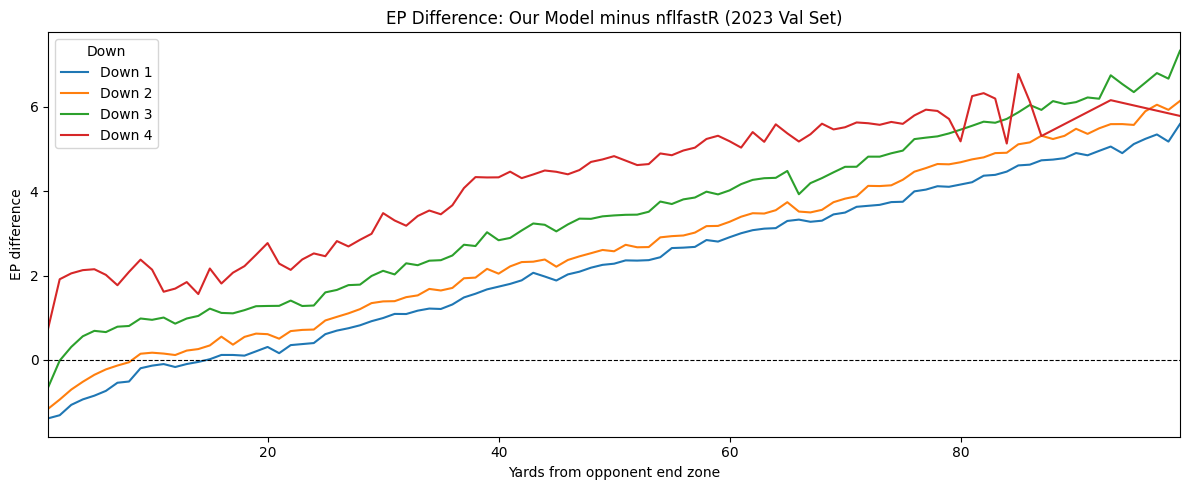

In [40]:
# Cell 9 -- EP difference: our model minus nflfastR by down
# Plotting the gap directly is more informative than eyeballing two separate
# curves. Positive values mean our model assigns higher EP than nflfastR.
# The gap is expected to be large and systematic given the known limitation
# documented in FINDINGS.md: our model anchors near the off_td base rate
# regardless of field position because next_score is defined at the game
# level and we lack drive context features.
fig, ax = plt.subplots(figsize=(12, 5))

for down in downs:
    ydstogo = TYPICAL_YDSTOGO[down]
    rows = []
    for yl in yard_lines:
        rows.append({
            "down_2":                       1 if down == 2 else 0,
            "down_3":                       1 if down == 3 else 0,
            "down_4":                       1 if down == 4 else 0,
            "ydstogo_log_scaled":           scale_ydstogo_log(ydstogo),
            "yardline_100_scaled":          scale(yl, "yardline_100"),
            "yardline_100_sq_scaled":       scale(yl ** 2, "yardline_100_sq"),
            "score_differential_scaled":    scale(0, "score_differential"),
            "half_seconds_remaining_scaled":scale(1800, "half_seconds_remaining"),
            "is_red_zone_scaled":           scale(1 if yl <= 20 else 0, "is_red_zone"),
        })

    X_grid = pd.DataFrame(rows)[FEATURES].values
    our_ep = xgb.predict_proba(X_grid) @ ep_values

    subset = val_merged[val_merged["down"] == down]
    nflfastr_avg = subset.groupby("yardline_100")["ep"].mean()

    common_yards = [yl for yl in yard_lines if yl in nflfastr_avg.index]
    our_ep_common = our_ep[[yl - 1 for yl in common_yards]]
    nflfastr_common = nflfastr_avg.loc[common_yards].values

    diff = our_ep_common - nflfastr_common
    ax.plot(common_yards, diff, label=f"Down {down}")

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("EP Difference: Our Model minus nflfastR (2023 Val Set)", fontsize=12)
ax.set_xlabel("Yards from opponent end zone")
ax.set_ylabel("EP difference")
ax.legend(title="Down")
ax.set_xlim(1, 99)

plt.tight_layout()
plt.savefig("figures/ep_difference.png", dpi=150, bbox_inches="tight")
plt.show()

In [41]:
# Cell 10 -- numeric summary of EP difference by zone
# The plots show the shape of the divergence. This table quantifies it.
# Mean absolute error tells us how far off our EP estimates are on average
# within each field position zone. The gap is largest in own territory where
# nflfastR assigns near-zero or negative EP and our model stays near 4.5.
# That is the direct consequence of lacking drive context features.

def zone_label(yl):
    if yl >= 71:
        return "Own territory (71-99)"
    elif yl >= 41:
        return "Midfield (41-70)"
    elif yl >= 21:
        return "Opp territory (21-40)"
    else:
        return "Red zone (1-20)"

zones = ["Own territory (71-99)", "Midfield (41-70)", "Opp territory (21-40)", "Red zone (1-20)"]

val_merged["ep_model"] = val["ep_model"].values

print(f"{'Zone':<28} {'Mean EP (Ours)':>15} {'Mean EP (nflfastR)':>18} {'MAE':>8}")
print("-" * 72)

for zone in zones:
    mask = val_merged["yardline_100"].apply(zone_label) == zone
    subset = val_merged[mask].dropna(subset=["ep", "ep_model"])
    if len(subset) == 0:
        continue
    our_mean   = subset["ep_model"].mean()
    their_mean = subset["ep"].mean()
    mae        = (subset["ep_model"] - subset["ep"]).abs().mean()
    print(f"{zone:<28} {our_mean:>15.3f} {their_mean:>18.3f} {mae:>8.3f}")

Zone                          Mean EP (Ours) Mean EP (nflfastR)      MAE
------------------------------------------------------------------------
Own territory (71-99)                  4.499              0.453    4.047
Midfield (41-70)                       4.550              1.794    2.759
Opp territory (21-40)                  4.691              3.359    1.361
Red zone (1-20)                        4.930              4.793    0.709
